# 2025-07-04: Clean up BMMC Plasma Cells [Stochastic]
### By [Aishwarya Chander](aishwarya.chander@alleninstitute.org), High Resolution Translational Immunology, Allen Institute for Immunology
**Main aim**: 

Using the messy object as the input, I'll now use common markers that are linked to plasma and tumor to iteratively separate and subcluster plasma cells from the rest of the cells.
The plasma cells are categorized into tumor like and healthy like groups. This is because some of these come from healthy patients but within the multiple myeloma cohort, there's no good way of _actually_ calling something a healthy tumor cell. Past exploration efforts included using methods like `InferCNV` to try and seaparate true healthy cells. We've now settled on a _healthy-like_ classification where the transcriptome resembles healthy plasma cells. 

## 1. Imports

In [2]:
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import os
import scanpy.external as sce
import anndata as ad

sc.settings.n_jobs = 30
sc.settings.verbosity = 0

plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (6, 5)

import sys
sys.path.insert(0, '../../00-utilities/functions/python/')
from process_scrna_data import process_adata

In [ ]:
plasma_dir = '../../../data/rna/plasma/'
if not os.path.exists(plasma_dir):
    os.makedirs(plasma_dir)

## 2. Process object
> Start with the raw data object. Then, add in the plasma cell IDs from the subject level plasma cell analysis. 

In [4]:
all_raw = sc.read_h5ad('../../../data/rna/raw-files/all-bmmc-raw.h5ad')
raw_plasma = sc.read_h5ad(plasma_dir+'messy_raw_plasma.h5ad')

plasma_cells = all_raw[all_raw.obs['cell_uuid'].isin(raw_plasma.obs['cell_uuid'])].copy()
plasma_cells.raw = plasma_cells

In [5]:
raw_plasma = None
all_raw = None

> This contains many cells that are not plasma cells as it uses the mode per leiden cluster to assign cell types. Processing this will give us the first pass of an object that I'll iteratively clean up to get to the final set of plasma cells using key marker genes.

In [6]:
plasma_cells = process_adata(plasma_cells, run_harmony=True)

2025-07-28 00:24:56,830 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-28 00:25:02,215 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-28 00:25:02,723 - harmonypy - INFO - Iteration 1 of 10
2025-07-28 00:25:55,141 - harmonypy - INFO - Iteration 2 of 10
2025-07-28 00:26:47,775 - harmonypy - INFO - Iteration 3 of 10
2025-07-28 00:27:41,052 - harmonypy - INFO - Iteration 4 of 10
2025-07-28 00:28:34,121 - harmonypy - INFO - Iteration 5 of 10
2025-07-28 00:29:27,390 - harmonypy - INFO - Converged after 5 iterations


## 3. Clean up

### 3.1. Clean up other cell types
> Drop any cells that express key markers for other cell types or doublets. 

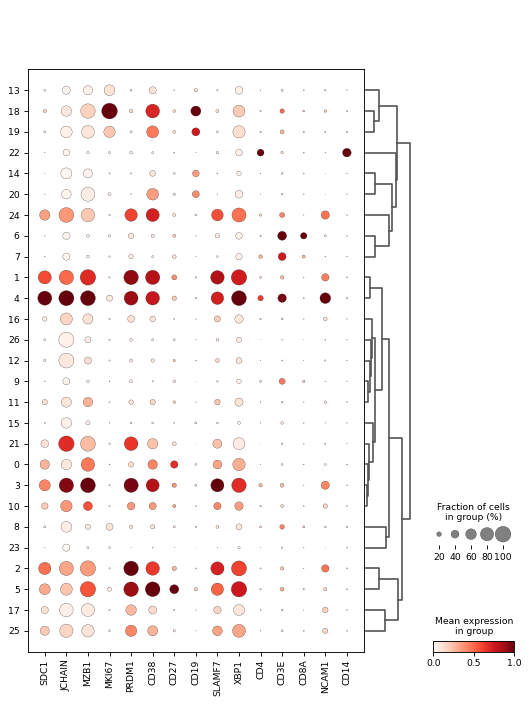

In [7]:
sc.tl.dendrogram(plasma_cells, groupby='leiden')
sc.pl.dotplot(
    plasma_cells,
    var_names=['SDC1', 'JCHAIN', 'MZB1', 'MKI67', 'PRDM1', 'CD38', 'CD27',
               'CD19', 'SLAMF7', 'XBP1', 'CD4', 'CD3E', 'CD8A', 'NCAM1', 'CD14'],
    groupby='leiden',
    standard_scale='var',
    cmap='Reds',
    dendrogram=True
)

In [8]:
plasma_groups = ['0', '1', '2', '3', '4', '5', '10', '11', '16', '17', '24', '25']

plasma_cells.obs.loc[
    plasma_cells.obs['leiden'].isin(plasma_groups),
    'plasma_label'
] = 'plasma'

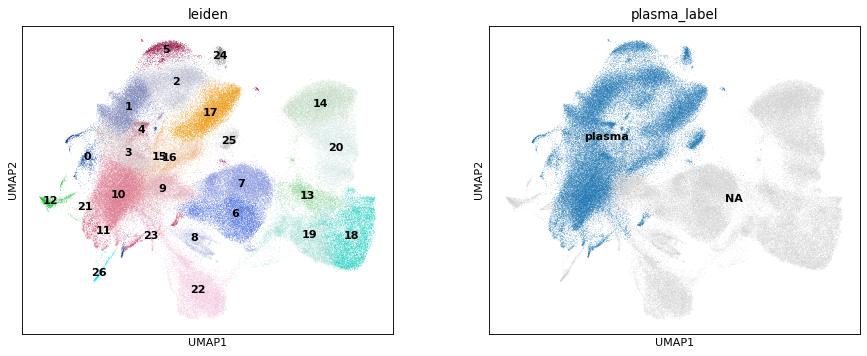

In [9]:
sc.pl.umap(plasma_cells, color=['leiden', 'plasma_label'], legend_loc='on data')

### 3.2. Clean up clusters with low plasma gene expression

In [10]:
plasma_cells = plasma_cells[plasma_cells.obs['plasma_label'] == 'plasma']
plasma_cells = process_adata(plasma_cells, run_harmony=False)

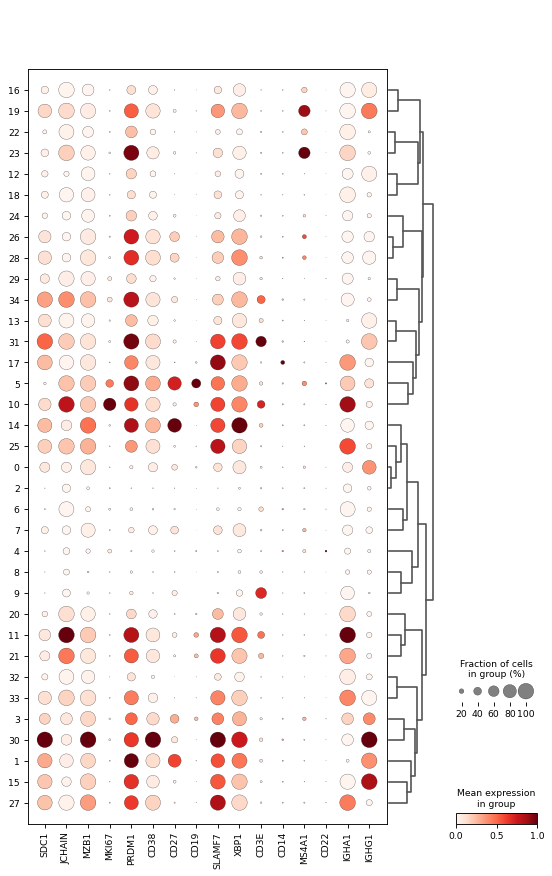

In [11]:
sc.tl.dendrogram(plasma_cells, groupby='leiden')
sc.pl.dotplot(
    plasma_cells,
    var_names=['SDC1', 'JCHAIN', 'MZB1', 'MKI67', 'PRDM1', 'CD38', 'CD27', 
               'CD19', 'SLAMF7', 'XBP1', 'CD3E', 'CD14', 'MS4A1', 'CD22', 'IGHA1', 'IGHG1'],
    groupby='leiden',
    standard_scale='var',
    cmap='Reds',
    dendrogram=True
)

In [12]:
plasma_cells = plasma_cells[~plasma_cells.obs['leiden'].isin(['8', '4', '2', '6', '9'])]
plasma_cells = process_adata(plasma_cells, run_harmony=False)

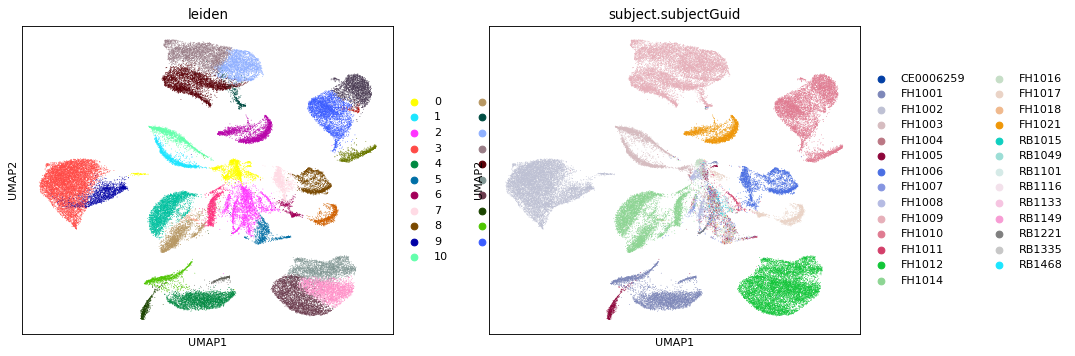

In [13]:
sc.pl.umap(plasma_cells, color=['leiden', 'subject.subjectGuid'])

### 3.3.1. Identify plasma cell states
> At this point we're down to only plasma cells but there's some that cocluster with the healthy cells and could potentially be healthy-like or non-tumor states.

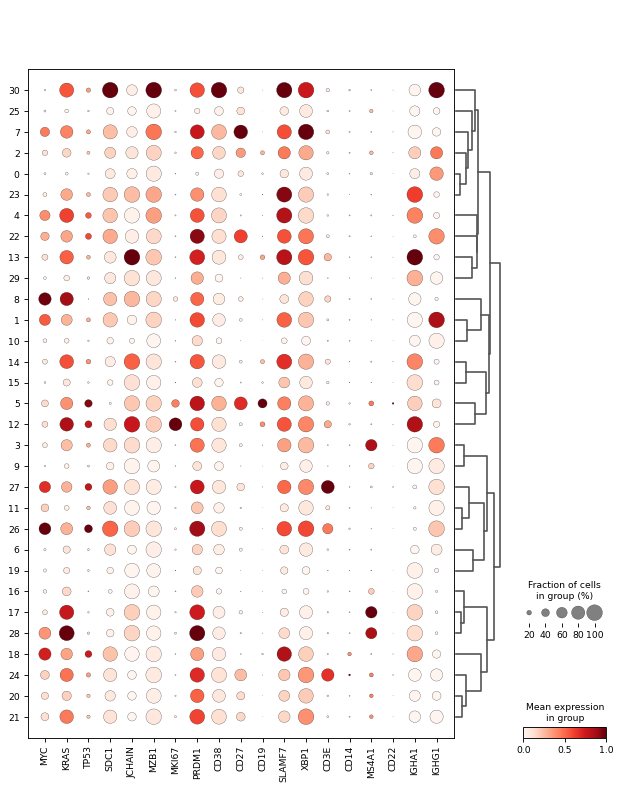

In [14]:
sc.tl.dendrogram(plasma_cells, groupby='leiden')
sc.pl.dotplot(
    plasma_cells,
    var_names=['MYC', 'KRAS', 'TP53', 'SDC1', 'JCHAIN', 'MZB1', 'MKI67', 'PRDM1', 'CD38', 'CD27', 
               'CD19', 'SLAMF7', 'XBP1', 'CD3E', 'CD14', 'MS4A1', 'CD22', 'IGHA1', 'IGHG1'],
    groupby='leiden',
    standard_scale='var',
    cmap='Reds',
    dendrogram=True
)

In [15]:
plasma_cells.obs['plasma_label'] = plasma_cells.obs['plasma_label'].fillna('plasma')

> To look into local features instead of global features, I'll use TSNE instead of UMAPs.

In [16]:
sc.tl.tsne(plasma_cells, n_pcs=30)

/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  warnings.warn(


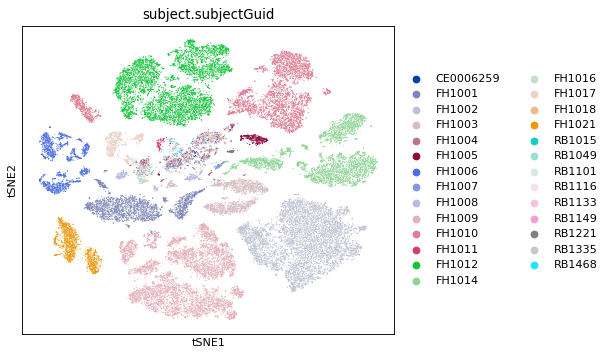

In [17]:
sc.pl.tsne(plasma_cells, color = 'subject.subjectGuid')

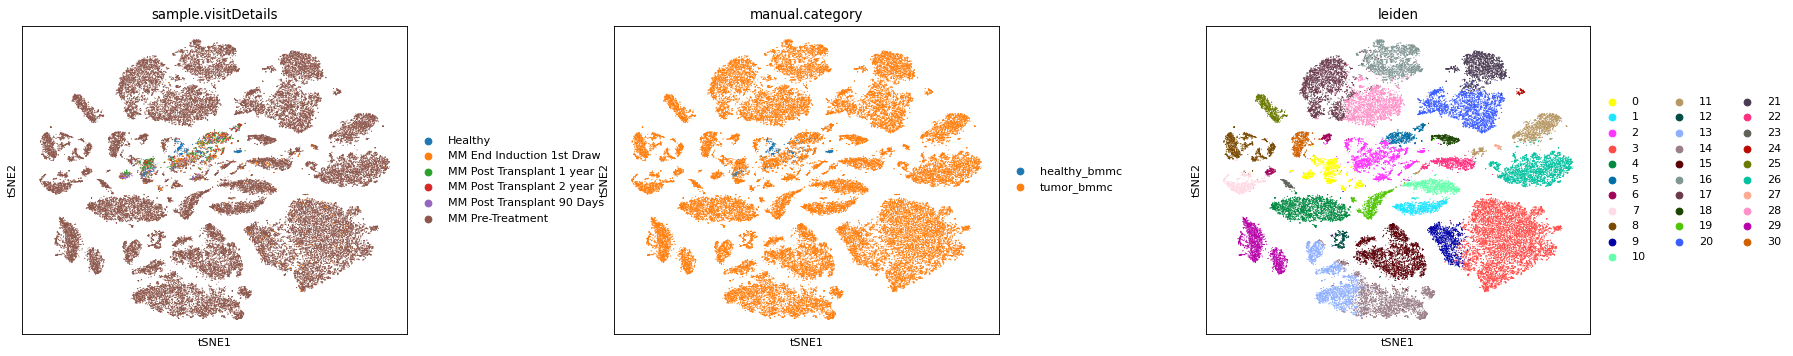

In [18]:
sc.pl.tsne(plasma_cells, color = ['sample.visitDetails', 'manual.category', 'leiden'], size=3, wspace=0.4)

### 3.3.2. Subcluster further to identify healthy states from tumor states

In [9]:
plasma_groups = ['0', '2', '5']

plasma_cells.obs.loc[
    plasma_cells.obs['leiden'].isin(plasma_groups),
    'maybe_healthy'
] = 'healthy_like'

healthy_like = plasma_cells[plasma_cells.obs['maybe_healthy'] == 'healthy_like']
healthy_like = process_adata(healthy_like, run_harmony=False)
sc.tl.tsne(healthy_like, n_pcs=30)

/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  warnings.warn(


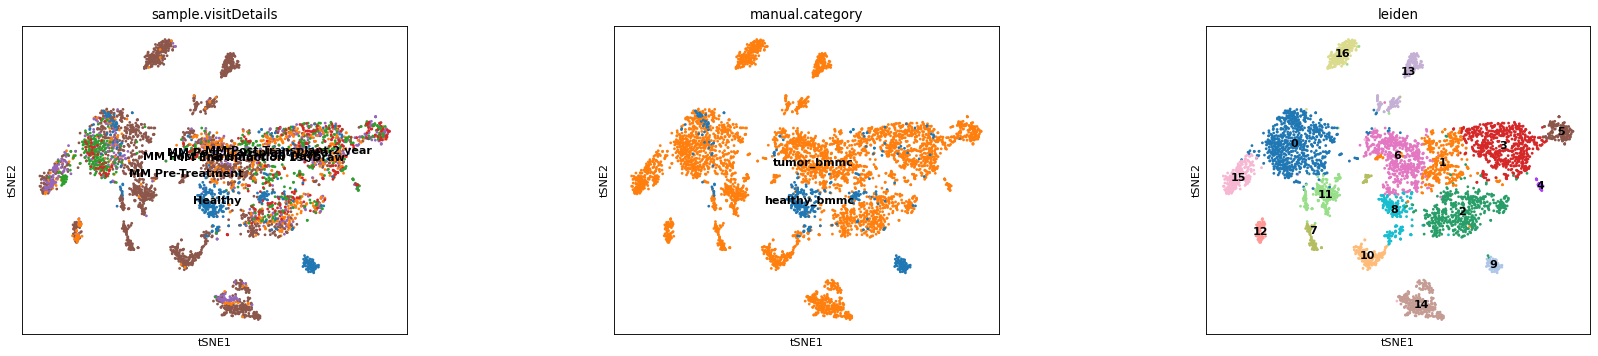

In [20]:
sc.pl.tsne(healthy_like, color = ['sample.visitDetails', 'manual.category', 'leiden'], legend_loc='on data', wspace=0.4)

### 3.4. Add in labels

In [29]:
leiden_to_label = {'0': 'healthy_like',
 '1': 'healthy_like',
 '2': 'healthy_like',
 '3': 'healthy_like',
 '4': 'plasma',
 '5': 'plasma',
 '6': 'healthy_like',
 '7': 'plasma',
 '8': 'healthy_like',
 '9': 'healthy_like',
 '10': 'plasma',
 '11': 'healthy_like',
 '12': 'plasma',
 '13': 'plasma',
 '14': 'plasma',
 '15': 'plasma',
 '16': 'plasma'}

healthy_like.obs['cell_states'] = healthy_like.obs['leiden'].map(leiden_to_label).astype('category').cat.remove_unused_categories()

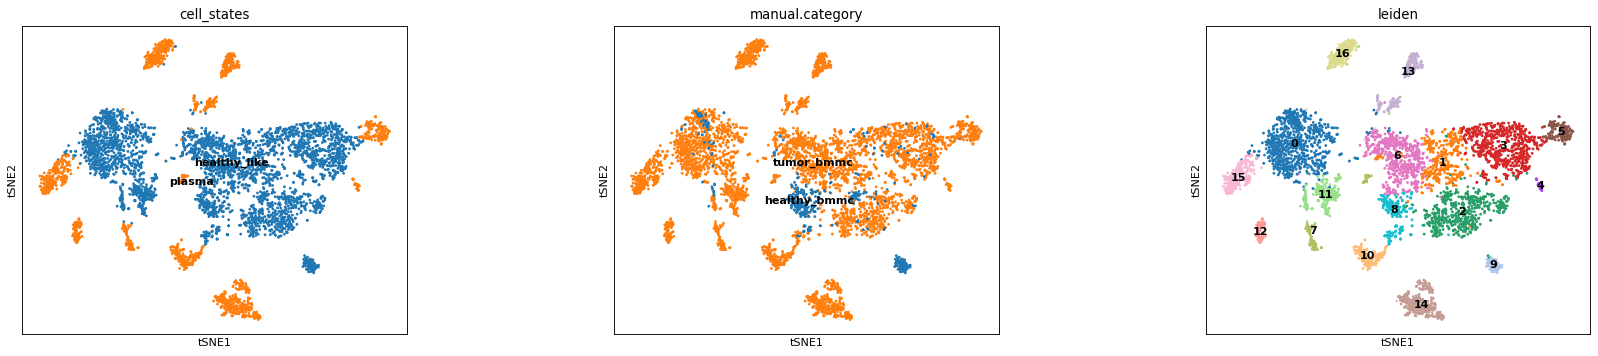

In [30]:
sc.pl.tsne(healthy_like, color = ['cell_states', 'manual.category', 'leiden'], legend_loc='on data', wspace=0.4)

### 3.5. Add in plasma cell states to the master object

In [31]:
labs = healthy_like.obs[['cell_states']]
plasma_cells.obs = plasma_cells.obs.merge(labs, on='barcodes', how='left')
plasma_cells.obs['cell_states'] = plasma_cells.obs['cell_states'].fillna('plasma')

## 4. Save all plasma cells

In [36]:
plasma_cells.write(plasma_dir+'all-plasma-cells.h5ad')
plasma_cells.obs.to_parquet(plasma_dir+'all-plasma-metadata.parquet')

## 5. Subset to pre-treatment plasma cells that are not healthy like
> This is our tumor cohort. 

In [47]:
pretx_plasma = plasma_cells[
    (plasma_cells.obs['cell_states'] == 'plasma') &
    (plasma_cells.obs['sample.visitDetails'] == 'MM Pre-Treatment')
]

> To limit techincal and biological effects that are indepentent of tumor biology, I'll exclude immunoglobulin genes, mitochondrial genes and ribodomal genes. Theres also a weird HBB inflection that seems techincal and not biological. 

In [50]:
pretx_plasma = pretx_plasma.raw.to_adata()

mt_mask = pretx_plasma.var_names.str.startswith("MT-")
ribo_mask = pretx_plasma.var_names.str.startswith(("RPS", "RPL"))
hb_mask = pretx_plasma.var_names.str.contains("^HB[^(P)]")
ig_mask = pretx_plasma.var_names.str.startswith(('IGK', 'IGL', 'IGH'))

mask = mt_mask | ribo_mask | hb_mask| ig_mask
pretx_plasma = pretx_plasma[:, ~mask]

pretx_plasma.raw = pretx_plasma

In [53]:
pretx_plasma = process_adata(pretx_plasma, resolution=0.5, run_harmony=True)
sc.tl.tsne(pretx_plasma, n_pcs=30)

2025-07-28 14:35:32,737 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-28 14:35:34,728 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-28 14:35:34,940 - harmonypy - INFO - Iteration 1 of 10
2025-07-28 14:35:46,754 - harmonypy - INFO - Iteration 2 of 10
2025-07-28 14:35:58,757 - harmonypy - INFO - Converged after 2 iterations
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  warnings.warn(


## 6. Save all PreTx cells

In [64]:
pretx_plasma.write(plasma_dir+'pretx-plasma-cells.h5ad')